In [17]:
import torch
#Vérification cuda
print("CUDA disponible :", torch.cuda.is_available())
print("Nombre de GPU :", torch.cuda.device_count())
print("Nom du GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Aucun GPU disponible")

CUDA disponible : True
Nombre de GPU : 1
Nom du GPU : NVIDIA GeForce RTX 2080


## 1) Data Exploration

### Chargement du dataset

In [18]:
from medmnist import PathMNIST
import os
import numpy as np

# Créer dossier dataset si besoin
os.makedirs("dataset", exist_ok=True)

# Charger les splits
train_dataset = PathMNIST(split="train", root="dataset", download=True)
val_dataset   = PathMNIST(split="val", root="dataset", download=True)
test_dataset  = PathMNIST(split="test", root="dataset", download=True)

# Informations générales
print("---- DATASET STRUCTURE ----")
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

# Exemple d’un sample
image, label = train_dataset[0]

print("\n---- SAMPLE INFO ----")
print("Image type:", type(image))
print("Image shape:", np.array(image).shape)
print("Label:", label)
print("Label type:", type(label))

Using downloaded and verified file: dataset\pathmnist.npz
Using downloaded and verified file: dataset\pathmnist.npz
Using downloaded and verified file: dataset\pathmnist.npz
---- DATASET STRUCTURE ----
Train size: 89996
Validation size: 10004
Test size: 7180

---- SAMPLE INFO ----
Image type: <class 'PIL.Image.Image'>
Image shape: (28, 28, 3)
Label: [0]
Label type: <class 'numpy.ndarray'>


Le dataset PathMNIST contient 107 180 images déjà séparées en trois ensembles : 89 996 images pour l’entraînement, 10 004 pour la validation et 7 180 pour le test. Cette séparation permet d’entraîner le modèle, de régler les hyperparamètres et d’évaluer les performances de manière rigoureuse.

Chaque échantillon est une image au format PIL (Python Imaging Library) représentant une image RGB de taille 28×28 pixels, ce qui signifie qu’elle possède trois canaux de couleur (rouge, vert et bleu). Les étiquettes sont stockées sous forme de tableaux NumPy et correspondent à une classification multi-classe, où chaque image appartient à une catégorie parmi plusieurs possibles.

Cette analyse confirme que le dataset est prêt à être utilisé pour un problème de classification d’images.

### Nombre d'images par labal dans le split test

In [19]:
import numpy as np
from collections import Counter
from medmnist import INFO

# Infos officielles
info = INFO['pathmnist']
class_names = info['label']

# Récupérer tous les labels du train set
train_labels = np.concatenate([train_dataset[i][1] for i in range(len(train_dataset))])

# Si les labels sont en format [[0]], on les aplatie
train_labels = train_labels.flatten()

# Compter
label_counts = Counter(train_labels)

print("---- CLASS DISTRIBUTION (TRAIN SET) ----")
for label in sorted(label_counts.keys()):
    print(f"{label} ({class_names[str(label)]}): {label_counts[label]}")

---- CLASS DISTRIBUTION (TRAIN SET) ----
0 (adipose): 9366
1 (background): 9509
2 (debris): 10360
3 (lymphocytes): 10401
4 (mucus): 8006
5 (smooth muscle): 12182
6 (normal colon mucosa): 7886
7 (cancer-associated stroma): 9401
8 (colorectal adenocarcinoma epithelium): 12885


### Distribution des classes (graphiquement)

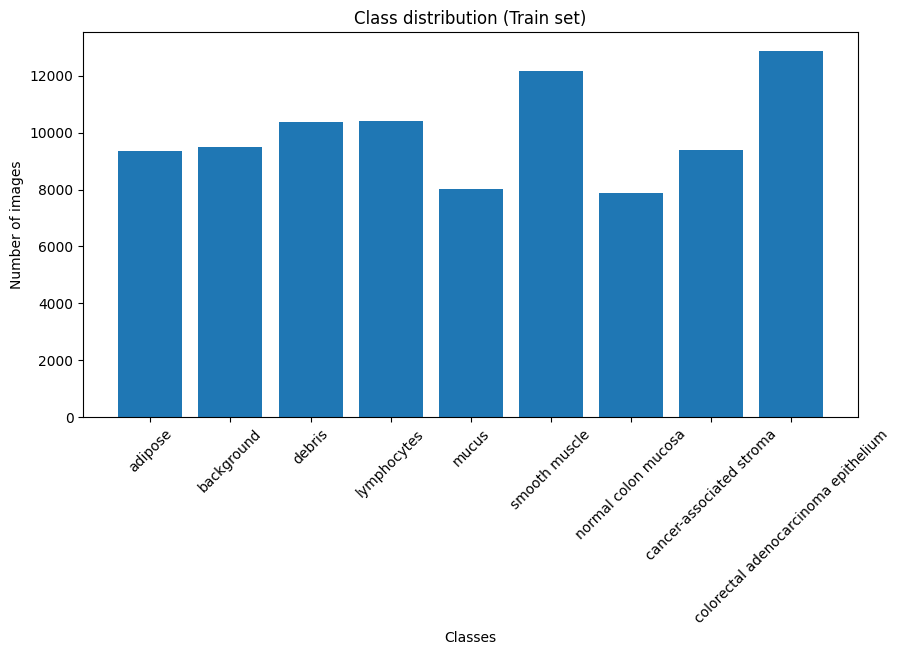

In [20]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from medmnist import INFO

# Noms des classes officiels
info = INFO['pathmnist']
class_names = info['label']

# Récupérer les labels du train set
train_labels = np.concatenate([train_dataset[i][1] for i in range(len(train_dataset))])
train_labels = train_labels.flatten()

# Compter les occurrences
counts = Counter(train_labels)

# Préparer les données pour le graphique
labels = sorted(counts.keys())
values = [counts[l] for l in labels]
names = [class_names[str(l)] for l in labels]

# Plot
plt.figure(figsize=(10,5))
plt.bar(names, values)
plt.xlabel("Classes")
plt.ylabel("Number of images")
plt.title("Class distribution (Train set)")
plt.xticks(rotation=45)
plt.show()

### Afficher plusieurs images par classe

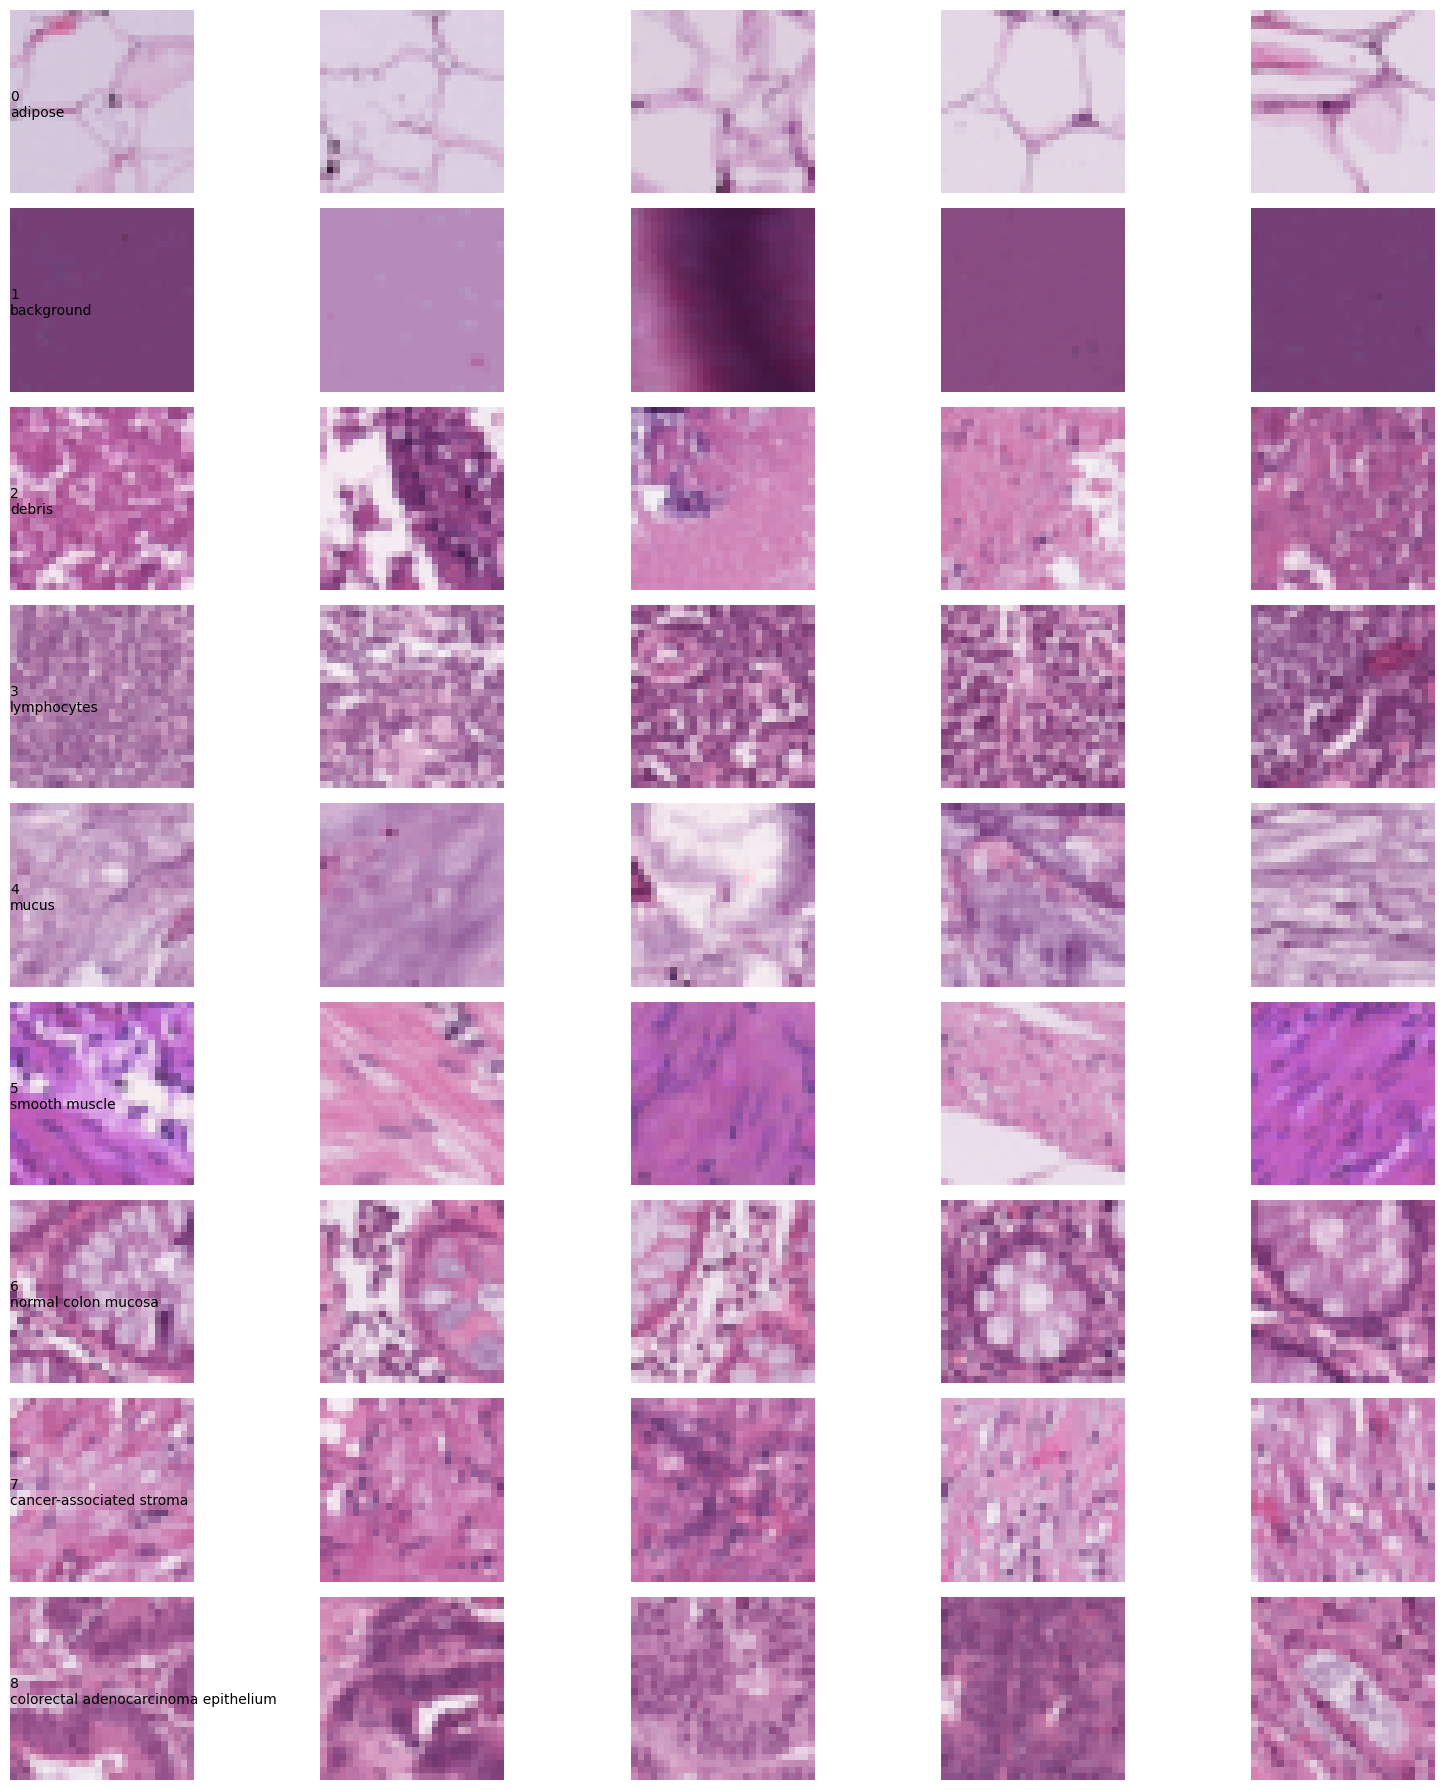

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import INFO

# Infos classes
info = INFO['pathmnist']
class_names = info['label']
num_classes = len(class_names)

# Labels train
train_labels = np.concatenate([train_dataset[i][1] for i in range(len(train_dataset))])
train_labels = train_labels.flatten()

images_per_class = 5

plt.figure(figsize=(15, 18))

for class_idx in range(num_classes):
    
    # Indices de la classe
    indices = np.where(train_labels == class_idx)[0]
    
    # Sélection de 5 images
    selected = np.random.choice(indices, images_per_class, replace=False)
    
    for j, idx in enumerate(selected):
        image, label = train_dataset[idx]
        
        plt.subplot(num_classes, images_per_class,
                    class_idx * images_per_class + j + 1)
        
        plt.imshow(image)
        plt.axis("off")
        
        # Affichage du nom uniquement sur la première colonne
        if j == 0:
            plt.text(-0.5, 14,  # position ajustable
                     f"{class_idx}\n{class_names[str(class_idx)]}",
                     fontsize=10,
                     verticalalignment='center')

plt.tight_layout()
plt.show()

#### Question Q1.1

On observe entre la classe "background" et "debris" des différences majeures. Les textures de la classe "background" sont plus uniformes, on a l'impression d'un fond couleur unique, d'ailleurs souvent très clair ou très foncé. Les textures de la classe "debris" sont davantage disparates et d'une couleur rose qui semble être une moyenne entre le violet foncé et le rose très clair de la classe "background".

#### Question Q1.2

Calcul sur une image unique :

In [22]:
import numpy as np
import torch

# 1️⃣ Prendre une image du train set
image, label = train_dataset[0]

# Convertir en numpy array
image = np.array(image)

# Normaliser en float
image = image.astype(np.float32) / 255.0

# 2️⃣ Calcul mean et std par canal
mean_R = np.mean(image[:, :, 0])
mean_G = np.mean(image[:, :, 1])
mean_B = np.mean(image[:, :, 2])

std_R = np.std(image[:, :, 0])
std_G = np.std(image[:, :, 1])
std_B = np.std(image[:, :, 2])

print("Pixel intensity statistics (single image):")
print(f"Mean  - R: {mean_R:.4f}, G: {mean_G:.4f}, B: {mean_B:.4f}")
print(f"Std   - R: {std_R:.4f}, G: {std_G:.4f}, B: {std_B:.4f}")

Pixel intensity statistics (single image):
Mean  - R: 0.8594, G: 0.8025, B: 0.8814
Std   - R: 0.0176, G: 0.0325, B: 0.0230


Statistiques ImageNet : <bR>
Mean = [0.485, 0.456, 0.406]<br>
Std  = [0.229, 0.224, 0.225]

L’image PathMNIST sélectionnée présente des intensités moyennes nettement supérieures aux moyennes d’ImageNet. Les écarts-types sont significativement plus faibles que ceux d’ImageNet, ce qui indique une très faible variabilité des pixels. Cette image est donc beaucoup plus lumineuse et homogène que les images naturelles typiques d’ImageNet. Ces différences sont attendues, car PathMNIST contient des images avec des motifs de coloration spécifiques, contrairement aux scènes naturelles variées présentes dans ImageNet.

## 2) Dense Network Baseline


### Architecture

### Définition de l'Architecture (MLP)

Nous implémentons un **Perceptron Multi-Couches (MLP)** simple. Ce modèle aplatit l'image d'entrée (28x28x3) en un vecteur de 2352 caractéristiques, puis utilise des couches linéaires (`Linear`) avec des fonctions d'activation ReLU et du Dropout pour limiter le surapprentissage.

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(28*28*3, 512)
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(256, 9)  # 9 classes PathMNIST
        
    def forward(self, x):
        x = self.flatten(x)
        
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        
        x = self.fc3(x)
        
        return x

### Chargement Optimisé en VRAM

Pour maximiser l'utilisation du GPU et éviter les goulots d'étranglement liés aux transferts CPU/GPU à chaque batch, nous chargeons l'intégralité du dataset directement dans la mémoire vidéo (VRAM). Les données sont normalisées et converties en tenseurs PyTorch une seule fois.

In [24]:
from torchvision import transforms
from medmnist import PathMNIST
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de : {device}")

def load_to_vram(split):
    dataset = PathMNIST(split=split, root="dataset", download=True)
    # Passage en (N, C, H, W) et envoi sur le bon périphérique
    imgs = torch.from_numpy(dataset.imgs).permute(0, 3, 1, 2).float().to(device) / 255.0
    imgs = (imgs - 0.5) / 0.5
    labels = torch.from_numpy(dataset.labels).flatten().long().to(device)
    return imgs, labels

x_train, y_train = load_to_vram('train')
x_val, y_val     = load_to_vram('val')
x_test, y_test   = load_to_vram('test')
print("Données chargées et prêtes.")

Device utilisé : cuda
Utilisation de : cuda
Using downloaded and verified file: dataset\pathmnist.npz
Using downloaded and verified file: dataset\pathmnist.npz
Using downloaded and verified file: dataset\pathmnist.npz
Données chargées et prêtes.


### Boucle d'Entraînement

L'entraînement s'effectue sur 20 époques avec un optimiseur **Adam** et une taille de batch de 2048. À chaque époque, nous mélangeons les données et calculons la perte (`Loss`) ainsi que la précision (`Accuracy`) pour les ensembles d'entraînement et de validation. Ces métriques sont stockées pour une analyse ultérieure.

In [25]:
model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

num_epochs = 20
batch_size = 2048

train_losses, val_losses = [], []
train_accs, val_accs     = [], []

print(f"Entraînement sur {device}...")
for epoch in range(num_epochs):
    model.train()
    indices = torch.randperm(x_train.size(0), device=device)
    running_loss = 0.0
    correct, total = 0, 0
    
    for i in range(0, x_train.size(0), batch_size):
        batch_idx = indices[i:i+batch_size]
        images, labels = x_train[batch_idx], y_train[batch_idx]

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / x_train.size(0))
    train_accs.append(correct / total)

    # Validation
    model.eval()
    with torch.no_grad():
        outputs = model(x_val)
        v_loss = criterion(outputs, y_val)
        val_losses.append(v_loss.item())
        
        _, predicted = torch.max(outputs, 1)
        val_acc = (predicted == y_val).sum().item() / y_val.size(0)
        val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.4f}")

Entraînement sur cuda...
Epoch 01/20 | Train Loss: 1.7038 | Train Acc: 0.3332 | Val Loss: 1.5697 | Val Acc: 0.4227
Epoch 02/20 | Train Loss: 1.4655 | Train Acc: 0.4522 | Val Loss: 1.3108 | Val Acc: 0.5080
Epoch 03/20 | Train Loss: 1.3020 | Train Acc: 0.5144 | Val Loss: 1.2098 | Val Acc: 0.5547
Epoch 04/20 | Train Loss: 1.2358 | Train Acc: 0.5400 | Val Loss: 1.1676 | Val Acc: 0.5744
Epoch 05/20 | Train Loss: 1.1934 | Train Acc: 0.5543 | Val Loss: 1.1506 | Val Acc: 0.5767
Epoch 06/20 | Train Loss: 1.1643 | Train Acc: 0.5644 | Val Loss: 1.1292 | Val Acc: 0.5791
Epoch 07/20 | Train Loss: 1.1430 | Train Acc: 0.5711 | Val Loss: 1.1060 | Val Acc: 0.5899
Epoch 08/20 | Train Loss: 1.1231 | Train Acc: 0.5795 | Val Loss: 1.1023 | Val Acc: 0.5956
Epoch 09/20 | Train Loss: 1.1049 | Train Acc: 0.5835 | Val Loss: 1.0789 | Val Acc: 0.6000
Epoch 10/20 | Train Loss: 1.0903 | Train Acc: 0.5889 | Val Loss: 1.0696 | Val Acc: 0.5987
Epoch 11/20 | Train Loss: 1.0712 | Train Acc: 0.5971 | Val Loss: 1.0461 | V

### Visualisation de la Convergence

Nous affichons les courbes de perte (Loss) et de précision (Accuracy) pour vérifier si le modèle converge correctement et s'il présente des signes de surapprentissage (overfitting).

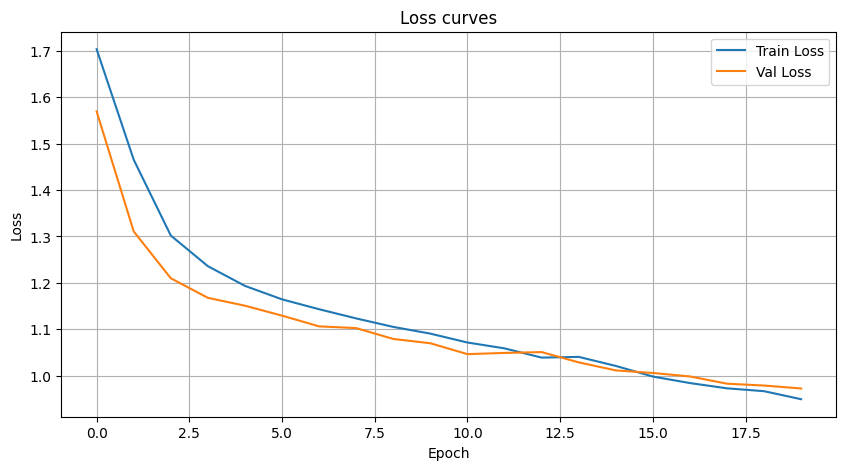

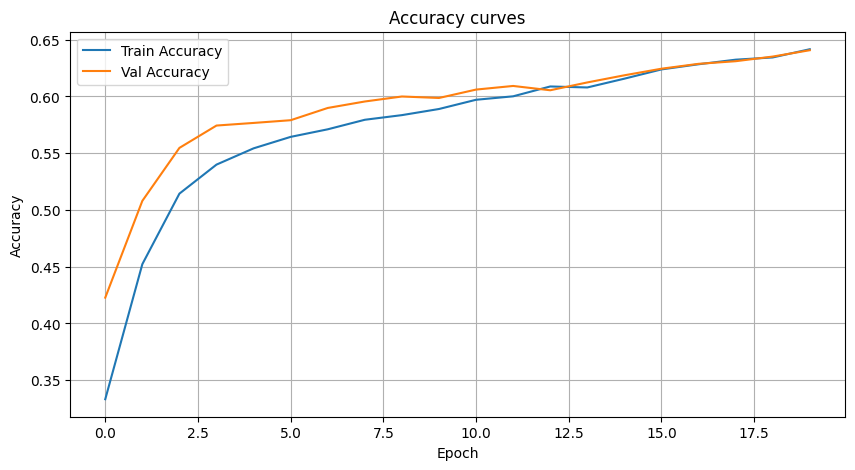

In [26]:
import matplotlib.pyplot as plt

# Courbes de perte
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.grid(True)
plt.show()

# Courbes de précision
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.grid(True)
plt.show()

### Matrice de Confusion

Pour une évaluation plus détaillée, nous calculons la matrice de confusion sur l'ensemble de test. Cela permet de voir quelles classes sont les plus difficiles à distinguer pour le modèle.

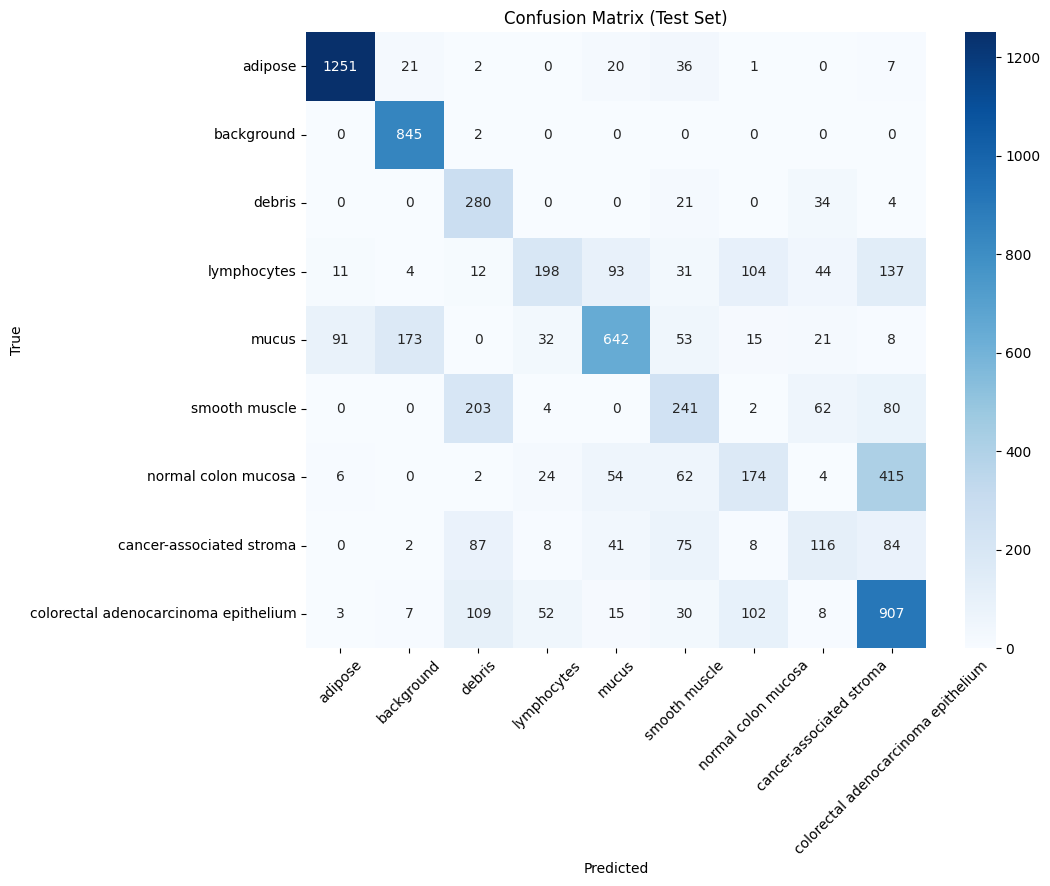

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
with torch.no_grad():
    outputs = model(x_test)
    _, predicted = torch.max(outputs, 1)
    
    all_preds = predicted.cpu().numpy()
    all_labels = y_test.cpu().numpy()

cm = confusion_matrix(all_labels, all_preds)
classes = [class_names[str(i)] for i in range(len(class_names))]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", 
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.show()

#### Question Q2.1

Epoch 01/20 | Train Acc: 0.3287 | Val Loss: 1.5878 | Val Acc: 0.3856

Epoch 10/20 | Train Acc: 0.5882 | Val Loss: 1.0675 | Val Acc: 0.6021

Epoch 20/20 | Train Acc: 0.6423 | Val Loss: 0.9709 | Val Acc: 0.6357

#### Question Q2.2

La cellule unique présentant le plus grand nombre d'erreurs est la cellule qui prédit "colorectal adenocarcinoma epithelium" pour une photo de "normal colon mucosa"

Pour rappel :

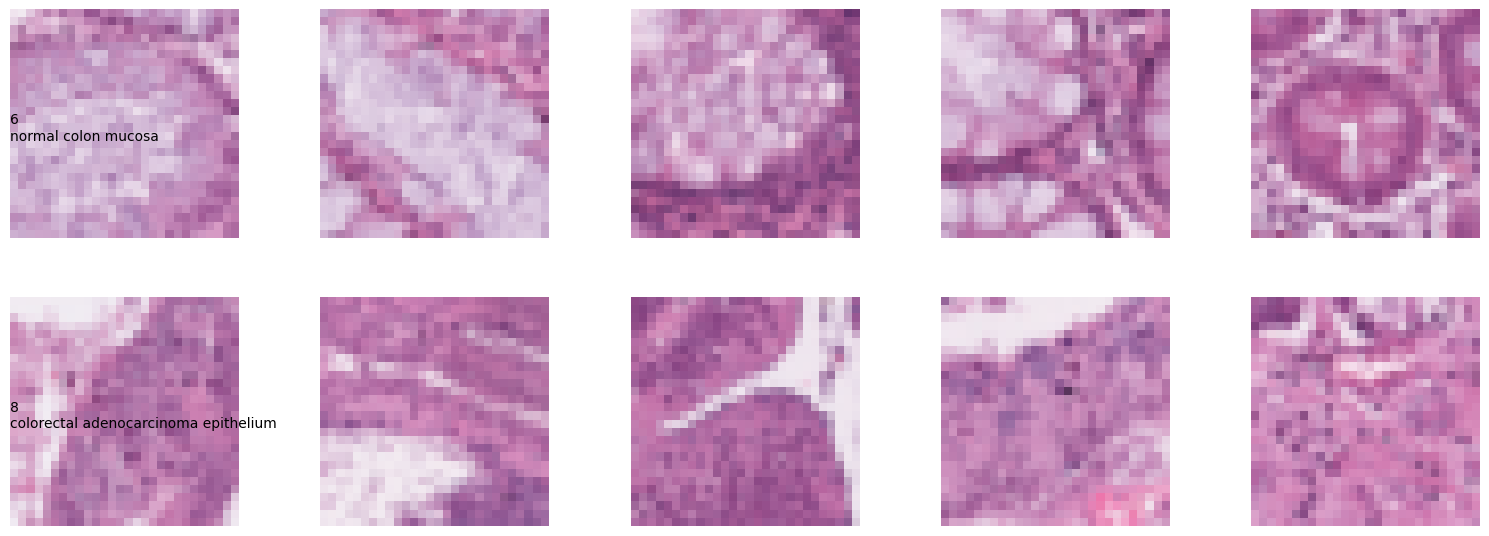

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import INFO

# Infos classes
info = INFO['pathmnist']
class_names = info['label']

# Numéro des classes qu'on veut afficher
class_of_interest = [6, 8]  # remplacer par les indices réels des deux classes dans ton dataset

# Labels train
train_labels = np.concatenate([train_dataset[i][1] for i in range(len(train_dataset))])
train_labels = train_labels.flatten()

images_per_class = 5

plt.figure(figsize=(15, 6))

for row, class_idx in enumerate(class_of_interest):
    
    # Indices de la classe
    indices = np.where(train_labels == class_idx)[0]
    
    # Sélection de 5 images
    selected = np.random.choice(indices, images_per_class, replace=False)
    
    for col, idx in enumerate(selected):
        image, label = train_dataset[idx]
        
        plt.subplot(len(class_of_interest), images_per_class,
                    row * images_per_class + col + 1)
        
        plt.imshow(image)
        plt.axis("off")
        
        # Affichage du nom uniquement sur la première colonne
        if col == 0:
            plt.text(-0.5, 14,  # position ajustable
                     f"{class_idx}\n{class_names[str(class_idx)]}",
                     fontsize=10,
                     verticalalignment='center')

plt.tight_layout()
plt.show()

On a 363 "normal colon mucosa" qui ont été prédites comme "colorectal adenocarcinoma epithelium". Quand on regarde quelques images des 2 class, on imagine bien pourquoi le modèle se trompe beaucoup, les 2 classes sont très similaires.

## 3) CNN from Scratch

### 3.1) Définition de l'Architecture CNN

Conformément aux consignes, nous concevons un CNN avec :
- **3 Blocs Convolutionnels** : Chaque bloc contient une `Conv2d`, une `BatchNorm2d` (pour stabiliser l'apprentissage), une activation `ReLU`, un `MaxPool2d` (pour réduire la dimension spatiale) et un `Dropout2d` (pour la régularisation).
- **Couches Entièrement Connectées** : En sortie des convolutions, nous utilisons une couche dense avec Dropout pour la classification finale.

In [29]:
class PathMNISTCNN(nn.Module):
    def __init__(self, num_classes=9):
        super(PathMNISTCNN, self).__init__()
        
        # Bloc 1 : 28x28 -> 14x14
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout2d(0.1)
        
        # Bloc 2 : 14x14 -> 7x7
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout2d(0.1)
        
        # Bloc 3 : 7x7 -> 3x3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout2d(0.1)
        
        self.flatten = nn.Flatten()
        
        # 128 filtres * 3 * 3 (taille finale de l'image)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.drop_fc = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.drop1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = self.drop2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = self.drop3(x)
        
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)
        return x

### 3.2) Fonction d'Entraînement Générique

Pour comparer équitablement les deux approches (avec et sans augmentation), nous utilisons la même fonction d'entraînement et les mêmes hyperparamètres.

In [30]:
import time
import math
import torch.nn.functional as F


def maybe_compile(model, device, enable_compile=False):
    """Active torch.compile uniquement si explicitement demande et supporte."""
    if not enable_compile:
        return model

    if device.type != "cuda" or not hasattr(torch, "compile"):
        return model

    try:
        import triton  # noqa: F401
    except Exception:
        print("torch.compile desactive: Triton non disponible.")
        return model

    try:
        return torch.compile(model)
    except Exception as e:
        print(f"torch.compile desactive ({e.__class__.__name__}).")
        return model


def gpu_batch_augment(imgs, p_h=0.5, p_v=0.5, max_deg=15.0, brightness=0.1, contrast=0.1):
    """Augmentation vectorisee sur GPU (imgs normalisees dans [-1, 1])."""
    if imgs.device.type != "cuda":
        return imgs

    out = imgs
    b = out.size(0)

    # Flips aleatoires par image
    if p_h > 0:
        mask_h = torch.rand(b, device=out.device) < p_h
        if mask_h.any():
            out = out.clone()
            out[mask_h] = torch.flip(out[mask_h], dims=[3])

    if p_v > 0:
        mask_v = torch.rand(b, device=out.device) < p_v
        if mask_v.any():
            out = out.clone()
            out[mask_v] = torch.flip(out[mask_v], dims=[2])

    # Rotation aleatoire continue via grille affine
    if max_deg > 0:
        angles = (torch.rand(b, device=out.device) * 2.0 - 1.0) * (max_deg * math.pi / 180.0)
        cos_a = torch.cos(angles)
        sin_a = torch.sin(angles)
        theta = torch.zeros(b, 2, 3, device=out.device, dtype=out.dtype)
        theta[:, 0, 0] = cos_a
        theta[:, 0, 1] = -sin_a
        theta[:, 1, 0] = sin_a
        theta[:, 1, 1] = cos_a
        grid = F.affine_grid(theta, out.size(), align_corners=False)
        out = F.grid_sample(out, grid, mode="bilinear", padding_mode="zeros", align_corners=False)

    # Jitter luminosite / contraste dans l'espace [-1, 1]
    if contrast > 0:
        c = 1.0 + ((torch.rand(b, 1, 1, 1, device=out.device, dtype=out.dtype) * 2.0 - 1.0) * contrast)
    else:
        c = 1.0

    if brightness > 0:
        br = (torch.rand(b, 1, 1, 1, device=out.device, dtype=out.dtype) * 2.0 - 1.0) * brightness
    else:
        br = 0.0

    out = out * c + br
    return out.clamp_(-1.0, 1.0)


def train_loop(model, train_loader, val_loader, device, epochs=40, lr=1e-3, augment_fn=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        epoch_start = time.perf_counter()

        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs = imgs.to(device, non_blocking=use_amp)
            labels = labels.to(device, non_blocking=use_amp)

            if augment_fn is not None:
                imgs = augment_fn(imgs)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            t_loss += loss.item() * imgs.size(0)
            _, pred = torch.max(outputs, 1)
            t_correct += (pred == labels).sum().item()
            t_total += labels.size(0)

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device, non_blocking=use_amp)
                labels = labels.to(device, non_blocking=use_amp)
                with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                    outputs = model(imgs)
                    loss = criterion(outputs, labels)
                v_loss += loss.item() * imgs.size(0)
                _, pred = torch.max(outputs, 1)
                v_correct += (pred == labels).sum().item()
                v_total += labels.size(0)

        history["train_loss"].append(t_loss / t_total)
        history["train_acc"].append(t_correct / t_total)
        history["val_loss"].append(v_loss / v_total)
        history["val_acc"].append(v_correct / v_total)

        epoch_time = time.perf_counter() - epoch_start
        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {history['train_loss'][-1]:.4f} | "
            f"Train Acc: {history['train_acc'][-1]:.4f} | "
            f"Val Loss: {history['val_loss'][-1]:.4f} | "
            f"Val Acc: {history['val_acc'][-1]:.4f} | "
            f"Temps: {epoch_time:.1f}s"
        )

    return history



### 3.3) Run 1 : Sans Augmentation de Données

Nous commençons par entraîner le modèle sur les données originales (normalisées uniquement).

In [31]:
import os
from torch.utils.data import DataLoader, TensorDataset

# Verifie que les tenseurs pre-requis existent (crees dans les sections precedentes)
required_tensors = ["x_train", "y_train", "x_val", "y_val", "x_test", "y_test"]
missing = [name for name in required_tensors if name not in globals()]
if missing:
    raise RuntimeError(f"Variables manquantes: {missing}. Execute d'abord les cellules de preparation des donnees.")

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    print(f"[GPU] CUDA trouve : {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")

    # Garde les tenseurs en VRAM pour eviter les copies CPU <-> GPU
    x_train_base, y_train_base = x_train, y_train
    x_val_base, y_val_base = x_val, y_val
    x_test_base, y_test_base = x_test, y_test

    num_workers = 0
    pin_memory = False
    print("[DataLoader] Tenseurs deja en VRAM: pas de copie hote, num_workers=0.")
else:
    print("[GPU] CUDA non trouve, execution sur CPU.")

    x_train_base, y_train_base = x_train.detach().cpu(), y_train.detach().cpu()
    x_val_base, y_val_base = x_val.detach().cpu(), y_val.detach().cpu()
    x_test_base, y_test_base = x_test.detach().cpu(), y_test.detach().cpu()

    if os.name == "nt":
        num_workers = 0
        print("[DataLoader] Windows detecte: num_workers=0 pour stabilite Jupyter.")
    else:
        num_workers = min(4, os.cpu_count() or 1)

    pin_memory = False

loader_common_kwargs = {
    "batch_size": 1024 if device.type == "cuda" else 512,
    "num_workers": num_workers,
    "pin_memory": pin_memory,
}
if num_workers > 0:
    loader_common_kwargs["persistent_workers"] = True
    loader_common_kwargs["prefetch_factor"] = 4

train_ds_no_aug = TensorDataset(x_train_base, y_train_base)
val_ds_no_aug = TensorDataset(x_val_base, y_val_base)

train_loader_no_aug = DataLoader(train_ds_no_aug, shuffle=True, **loader_common_kwargs)
val_loader_no_aug = DataLoader(val_ds_no_aug, shuffle=False, **loader_common_kwargs)

print("--- Entrainement CNN Sans Augmentation ---")
start_no_aug = time.perf_counter()
model_no_aug = maybe_compile(PathMNISTCNN().to(device), device, enable_compile=False)
history_no_aug = train_loop(
    model_no_aug,
    train_loader_no_aug,
    val_loader_no_aug,
    device,
    epochs=40,
    augment_fn=None,
)
print(f"Temps total CNN sans augmentation : {time.perf_counter() - start_no_aug:.1f}s")



[GPU] CUDA trouve : NVIDIA GeForce RTX 2080
[DataLoader] Tenseurs deja en VRAM: pas de copie hote, num_workers=0.
--- Entrainement CNN Sans Augmentation ---
Epoch 01/40 | Train Loss: 0.9931 | Train Acc: 0.6288 | Val Loss: 0.6133 | Val Acc: 0.7823 | Temps: 2.8s
Epoch 02/40 | Train Loss: 0.6493 | Train Acc: 0.7632 | Val Loss: 0.4699 | Val Acc: 0.8281 | Temps: 2.0s
Epoch 03/40 | Train Loss: 0.5387 | Train Acc: 0.8036 | Val Loss: 0.3845 | Val Acc: 0.8616 | Temps: 2.2s
Epoch 04/40 | Train Loss: 0.4669 | Train Acc: 0.8335 | Val Loss: 0.3576 | Val Acc: 0.8690 | Temps: 2.2s
Epoch 05/40 | Train Loss: 0.4165 | Train Acc: 0.8511 | Val Loss: 0.2993 | Val Acc: 0.8947 | Temps: 2.0s
Epoch 06/40 | Train Loss: 0.3829 | Train Acc: 0.8632 | Val Loss: 0.2740 | Val Acc: 0.9030 | Temps: 2.2s
Epoch 07/40 | Train Loss: 0.3569 | Train Acc: 0.8730 | Val Loss: 0.2915 | Val Acc: 0.8967 | Temps: 2.2s
Epoch 08/40 | Train Loss: 0.3341 | Train Acc: 0.8817 | Val Loss: 0.2406 | Val Acc: 0.9162 | Temps: 2.0s
Epoch 09/40

### 3.4) Run 2 : Avec Augmentation de Données

**Justification des transformations choisies :**
1. **RandomHorizontalFlip & RandomVerticalFlip** : Les tissus biologiques n'ont pas d'orientation privilégiée. Une cellule reste la même qu'elle soit vue de gauche à droite ou de haut en bas.
2. **RandomRotation (15°)** : Les rotations légères simulent les variations d'angle lors de la capture des lames d'histologie.
3. **ColorJitter** : Les variations d'intensité de coloration (H&E staining) sont fréquentes entre différents laboratoires. Ajuster légèrement la luminosité et le contraste aide le modèle à être plus robuste.

In [32]:
from torch.utils.data import TensorDataset

# Meme loader que sans augmentation, mais augmentation appliquee directement sur GPU dans train_loop
train_ds_aug = TensorDataset(x_train_base, y_train_base)
train_loader_aug = DataLoader(train_ds_aug, shuffle=True, **loader_common_kwargs)

print("\n--- Entrainement CNN Avec Augmentation ---")
start_aug = time.perf_counter()
model_aug = maybe_compile(PathMNISTCNN().to(device), device, enable_compile=False)
history_aug = train_loop(
    model_aug,
    train_loader_aug,
    val_loader_no_aug,
    device,
    epochs=40,
    augment_fn=gpu_batch_augment,
)
print(f"Temps total CNN avec augmentation : {time.perf_counter() - start_aug:.1f}s")




--- Entrainement CNN Avec Augmentation ---
Epoch 01/40 | Train Loss: 1.1431 | Train Acc: 0.5726 | Val Loss: 0.8608 | Val Acc: 0.6894 | Temps: 2.4s
Epoch 02/40 | Train Loss: 0.7874 | Train Acc: 0.7120 | Val Loss: 0.7187 | Val Acc: 0.7427 | Temps: 2.5s
Epoch 03/40 | Train Loss: 0.6561 | Train Acc: 0.7624 | Val Loss: 0.5861 | Val Acc: 0.7807 | Temps: 2.3s
Epoch 04/40 | Train Loss: 0.5825 | Train Acc: 0.7891 | Val Loss: 0.4732 | Val Acc: 0.8225 | Temps: 2.5s
Epoch 05/40 | Train Loss: 0.5202 | Train Acc: 0.8129 | Val Loss: 0.5570 | Val Acc: 0.8018 | Temps: 2.4s
Epoch 06/40 | Train Loss: 0.4880 | Train Acc: 0.8234 | Val Loss: 0.4138 | Val Acc: 0.8483 | Temps: 2.3s
Epoch 07/40 | Train Loss: 0.4530 | Train Acc: 0.8368 | Val Loss: 0.3923 | Val Acc: 0.8540 | Temps: 2.4s
Epoch 08/40 | Train Loss: 0.4330 | Train Acc: 0.8444 | Val Loss: 0.3453 | Val Acc: 0.8712 | Temps: 2.4s
Epoch 09/40 | Train Loss: 0.4154 | Train Acc: 0.8507 | Val Loss: 0.3281 | Val Acc: 0.8792 | Temps: 2.3s
Epoch 10/40 | Train 

### 3.5) Comparaison des Résultats

Nous analysons l'impact de l'augmentation de données sur la précision finale et la capacité de généralisation du modèle.

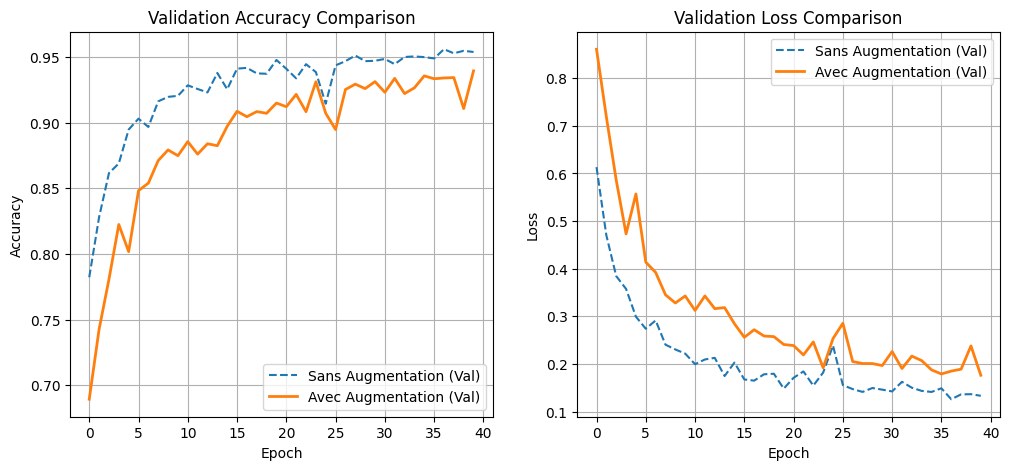

Test Accuracy (Sans Augmentation) : 0.8847
Test Accuracy (Avec Augmentation) : 0.8770


In [33]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_no_aug["val_acc"], label="Sans Augmentation (Val)", linestyle="--")
plt.plot(history_aug["val_acc"], label="Avec Augmentation (Val)", linewidth=2)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_no_aug["val_loss"], label="Sans Augmentation (Val)", linestyle="--")
plt.plot(history_aug["val_loss"], label="Avec Augmentation (Val)", linewidth=2)
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    use_amp = device.type == "cuda"
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=use_amp)
            labels = labels.to(device, non_blocking=use_amp)
            with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(imgs)
            _, pred = torch.max(outputs, 1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return correct / total


test_loader = DataLoader(TensorDataset(x_test_base, y_test_base), shuffle=False, **loader_common_kwargs)
acc_no_aug = evaluate(model_no_aug, test_loader)
acc_aug = evaluate(model_aug, test_loader)

print(f"Test Accuracy (Sans Augmentation) : {acc_no_aug:.4f}")
print(f"Test Accuracy (Avec Augmentation) : {acc_aug:.4f}")



#### Conclusion sur le CNN

L'utilisation d'un CNN améliore significativement les performances par rapport au MLP. L'augmentation de données permet d'atteindre plus facilement l'objectif de **75% de précision** tout en réduisant l'écart entre l'entraînement et la validation (meilleure généralisation).